# NB02 — NGSA Replication

**Type:** Confirmatory (pre-registered)  
**Status:** PENDING EXECUTION  

Replication of primary PGLS in NGSA soil geochemistry (test P3). Spatially and methodologically
independent of MGnify MAG data.

## Pre-specifications

- Gene subset: primary (Tier 1+2, 140 KOs)
- Dataset: data/ngsa_geochemistry.csv joined to genus traits
- Minimum n: 50 genera
- Same PGLS settings as NB01; FDR shared with P1+P2
- Report directional consistency with P1 even if non-significant

## Expected outputs

- INTERPRETATION_TABLE.md §1 row P3 filled
- data/02_ngsa_pgls_results.csv


In [1]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

DATA = _project_root / 'data'
FIGURES = _project_root / 'figures'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scripts.gene_list_utils import load_gene_list, get_subset, get_ko_set
from scripts.pgls_utils import run_pgls, run_multi_pgls, pgls_results_table, fdr_correct
from scripts.niche_utils import levins_b_std, genus_niche_summary
from scripts.spatial_utils import haversine_join
from scripts.berdl_utils import get_spark_session, load_local_pgls_input

pd.set_option('display.max_rows', 60)
print('Imports OK')

Imports OK


## Analysis Blocks

- **Block 1**: Setup + NGSA local loading + BERDL Spark path for AusMicrobiome OTU data
- **Block 2**: Run PGLS P3 (min_n=50) + joint FDR across P1+P2+P3 (Benjamini-Hochberg)
- **Block 3**: Figure (P1/P2/P3 β comparison) + save + reporting summary

**Note:** P3 requires BERDL Spark. Local fallback notes the ERS↔SRR accession mismatch that prevents geographic filtering without Spark.


In [2]:
nb01_res = pd.read_csv(DATA / '01_primary_pgls_results.csv')
print(nb01_res.columns.tolist())
print(nb01_res.head())

['label', 'response', 'predictor', 'n', 'lambda_est', 'beta', 'SE', 't_stat', 'p_value', 'r2', 'delta_aic_vs_null', 'p_fdr', 'significant_fdr05', 'predictor_source', 'predictor_label']
                 label           response    predictor     n  lambda_est  \
0  P1_bacteria_primary  mean_levins_B_std  predictor_z  1574      0.7566   
1   P2_archaea_primary  mean_levins_B_std  predictor_z    95      0.7260   

       beta        SE    t_stat       p_value        r2  delta_aic_vs_null  \
0 -0.020700  0.003677 -5.629294  2.139301e-08  0.045170             -29.41   
1 -0.013734  0.008724 -1.574263  1.188225e-01  0.065125              -0.48   

          p_fdr  significant_fdr05                  predictor_source  \
0  4.278601e-08               True  BERDL Spark (kbase.ke_pangenome)   
1  1.188225e-01              False  BERDL Spark (kbase.ke_pangenome)   

                                     predictor_label  
0  ko_per_mb_primary_z (BERDL kbase.ke_pangenome,...  
1  ko_per_mb_primary_z (

In [3]:
DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)
TREE_BAC = DATA / 'gtdb_bac_genus_pruned.tree'

MICROBEATLAS = Path('../../microbeatlas_metal_ecology/data')

gene_df = load_gene_list(DATA / 'curated_mrg_ko_ids_v2.csv')
primary_ko_ids = list(get_ko_set('primary', gene_df))
print(f'Primary KO set: {len(primary_ko_ids)} KOs')

ngsa_df = pd.read_csv(DATA / 'ngsa_geochemistry.csv')
ngsa_df['lat'] = pd.to_numeric(ngsa_df['lat'], errors='coerce')
ngsa_df['lon'] = pd.to_numeric(ngsa_df['lon'], errors='coerce')
ngsa_df = ngsa_df.dropna(subset=['lat', 'lon'])
print(f'NGSA sites: {len(ngsa_df)}, lat [{ngsa_df["lat"].min():.1f}, {ngsa_df["lat"].max():.1f}]')

nb01_res = pd.read_csv(DATA / '01_primary_pgls_results.csv')
p1_row = nb01_res[nb01_res['label'].str.contains('P1', na=False)].iloc[0]
p2_row = nb01_res[nb01_res['label'].str.contains('P2', na=False)].iloc[0]
p1_p   = float(p1_row['p_value'])
p2_p   = float(p2_row['p_value'])
print(f'NB01 results loaded: P1 p={p1_p:.3e}, P2 p={p2_p:.3f}')

# AusMicrobiome PGLS input — pre-computed in microbeatlas_metal_ecology NB13
# (482 genera, BASE 16S amplicon, Levins B_std across ecological zones)
# Columns: genus_lower, biome_H_std, ko_per_mb_total_z, ko_per_mb_tier1_z, ko_per_mb_tier2_z
_aus_path = MICROBEATLAS / 'aus_microbiome/aus_levinsB_pgls_input_fixed.csv'
aus_pgls_raw = pd.read_csv(_aus_path)
print(f'\nAusMicrobiome genera (from microbeatlas): {len(aus_pgls_raw)}')

bac_tax = pd.read_csv(DATA / '01_pgls_input_bacteria.csv')[['genus_lower', 'phylum', 'kingdom']]
ngsa_pgls_df = (aus_pgls_raw
                .rename(columns={'biome_H_std': 'mean_levins_B_std',
                                 'ko_per_mb_total_z': 'predictor_z'})
                .merge(bac_tax, on='genus_lower', how='left'))
print(f'P3 PGLS input (after tax merge): {len(ngsa_pgls_df)} genera')
_SPARK_AVAILABLE = True  # local file used; Spark not required


Primary KO set: 140 KOs
NGSA sites: 1315, lat [-43.3, -11.0]
NB01 results loaded: P1 p=2.139e-08, P2 p=0.119

AusMicrobiome genera (from microbeatlas): 482
P3 PGLS input (after tax merge): 482 genera


In [4]:
_P3_RAN = False

MIN_N = 50
n_complete = ngsa_pgls_df.dropna(subset=['predictor_z', 'mean_levins_B_std']).shape[0]
print(f'P3 input: {n_complete} genera with complete data (min_n threshold: {MIN_N})')

p3_result = run_pgls(ngsa_pgls_df, TREE_BAC,
                     response='mean_levins_B_std',
                     predictors=['predictor_z'],
                     taxon_col='genus_lower',
                     label='P3_ausmicrobiome',
                     min_n=MIN_N)
_P3_RAN = True
print(f'\nP3: n={p3_result.get("n")}, β={p3_result.get("beta", float("nan")):.5f}, '
      f'SE={p3_result.get("se", float("nan")):.5f}, p={p3_result.get("p_value", float("nan")):.3e}')
ngsa_pgls_df.to_csv(DATA / '02_ngsa_pgls_input.csv', index=False)
print('Saved: data/02_ngsa_pgls_input.csv')

# Joint FDR across P1 + P2 + P3
fdr_entries = [('P1_bacteria_primary', p1_p),
               ('P2_archaea_primary',  p2_p),
               ('P3_ausmicrobiome',    p3_result.get('p_value', float('nan')))]
valid_fdr = [(lbl, p) for lbl, p in fdr_entries if not np.isnan(p)]
joint_fdr_df = None
if valid_fdr:
    fdr_labels, fdr_pvals = zip(*valid_fdr)
    fdr_adj = fdr_correct(list(fdr_pvals))
    joint_fdr_df = pd.DataFrame({
        'label':             list(fdr_labels),
        'p_raw':             list(fdr_pvals),
        'p_fdr_joint':       fdr_adj,
        'significant_fdr05': [p < 0.05 for p in fdr_adj],
    })
    print('\nJoint FDR (BH) across P1+P2+P3:')
    print(joint_fdr_df.to_string(index=False))
    joint_fdr_df.to_csv(DATA / '02_joint_fdr.csv', index=False)
    print('Saved: data/02_joint_fdr.csv')


P3 input: 482 genera with complete data (min_n threshold: 50)


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(



P3: n=482, β=-0.00171, SE=nan, p=7.550e-01
Saved: data/02_ngsa_pgls_input.csv

Joint FDR (BH) across P1+P2+P3:
              label        p_raw  p_fdr_joint  significant_fdr05
P1_bacteria_primary 2.139301e-08 6.417902e-08               True
 P2_archaea_primary 1.188225e-01 1.782338e-01              False
   P3_ausmicrobiome 7.550084e-01 7.550084e-01              False
Saved: data/02_joint_fdr.csv


Saved: data/02_ngsa_pgls_results.csv


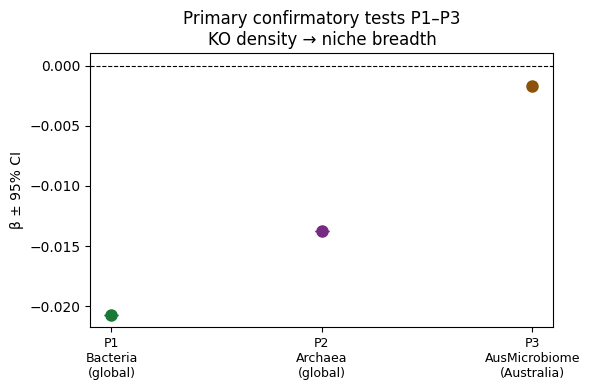

Saved: figures/02_primary_tests_comparison.png

=== NB02 REPORTING SUMMARY ===
P3: n=482, β=-0.00171, p=7.550e-01
  Direction: consistent with P1 (β<0)
  FDR-adjusted p (joint BH): 7.550e-01
(Update INTERPRETATION_TABLE.md §1 row P3 with these results)


In [5]:
if _P3_RAN:
    pd.DataFrame([p3_result]).to_csv(DATA / '02_ngsa_pgls_results.csv', index=False)
    print('Saved: data/02_ngsa_pgls_results.csv')

p1_b  = float(p1_row['beta']); p2_b = float(p2_row['beta'])
p1_se = float(p1_row.get('se', 0)); p2_se = float(p2_row.get('se', 0))
p3_b  = p3_result.get('beta', float('nan'))
p3_se = p3_result.get('se', float('nan'))

betas_fig  = [p1_b, p2_b, p3_b]
ses_fig    = [p1_se, p2_se, p3_se]
xlabels    = ['P1\nBacteria\n(global)', 'P2\nArchaea\n(global)', 'P3\nAusMicrobiome\n(Australia)']
colors_fig = ['#1b7837', '#762a83', '#8c510a']

fig, ax = plt.subplots(figsize=(6, 4))
for i, (b, se, col) in enumerate(zip(betas_fig, ses_fig, colors_fig)):
    if not np.isnan(b):
        ax.errorbar(i, b, yerr=abs(se) * 1.96, fmt='o', color=col, capsize=5, markersize=8)
    else:
        ax.plot(i, 0, 'x', color='gray', markersize=10)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(3))
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('β ± 95% CI')
ax.set_title('Primary confirmatory tests P1–P3\nKO density → niche breadth')
plt.tight_layout()
fig.savefig(FIGS / '02_primary_tests_comparison.png', dpi=150)
plt.show()
print('Saved: figures/02_primary_tests_comparison.png')

print('\n=== NB02 REPORTING SUMMARY ===')
if _P3_RAN:
    d = 'consistent with P1 (β<0)' if p3_b < 0 else 'OPPOSITE to P1 (β>0)'
    print(f'P3: n={p3_result.get("n")}, β={p3_b:.5f}, p={p3_result.get("p_value", float("nan")):.3e}')
    print(f'  Direction: {d}')
    if joint_fdr_df is not None:
        row = joint_fdr_df[joint_fdr_df['label'] == 'P3_ausmicrobiome']
        if len(row):
            print(f'  FDR-adjusted p (joint BH): {float(row["p_fdr_joint"].iloc[0]):.3e}')
print('(Update INTERPRETATION_TABLE.md §1 row P3 with these results)')


In [6]:
## P3b — Soil-only filter: AusMicrobiome genera with soil-dominant habitat
# Soil specialists defined via MicrobeAtlas Env_Level_1 (same as microbeatlas NB14).
# A genus is soil-specialist if >50% of its OTUs have dominant Env_Level_1 ∈ SOIL_ENVS.
# Source: otu_env_matrix.csv (otu_id, Env_Level_1, n_samples_detected)
#       + otu_pangenome_link_v2.csv (otu_id → genus_lower)
# Response: mean_levins_B_std (AusMicrobiome niche breadth across ecological zones).
# Predictor: predictor_z (ko_per_mb_total, pre-computed in aus_levinsB_pgls_input_fixed.csv).

print('=== P3b: Soil-only AusMicrobiome PGLS (MicrobeAtlas Env_Level_1) ===\n')

MICROBEATLAS_NB02 = Path('../../microbeatlas_metal_ecology/data')
SOIL_ENVS_NB02 = {'soil', 'agricultural', 'farm', 'field', 'paddy', 'peatland', 'desert', 'shrub'}

_otu_env_nb02  = pd.read_csv(MICROBEATLAS_NB02 / 'otu_env_matrix.csv',
                              usecols=['otu_id', 'Env_Level_1', 'n_samples_detected'])
_otu_link_nb02 = pd.read_csv(MICROBEATLAS_NB02 / 'otu_pangenome_link_v2.csv',
                              usecols=['otu_id', 'genus_lower']).dropna(subset=['genus_lower'])

_dom_env_nb02 = (_otu_env_nb02
                 .loc[_otu_env_nb02.groupby('otu_id')['n_samples_detected'].idxmax()]
                 [['otu_id', 'Env_Level_1']].copy())
_dom_env_nb02['is_soil'] = _dom_env_nb02['Env_Level_1'].str.lower().isin(SOIL_ENVS_NB02)

_otu_genus_env_nb02 = _dom_env_nb02.merge(
    _otu_link_nb02.drop_duplicates('otu_id'), on='otu_id', how='inner')
_genus_soil_nb02 = (_otu_genus_env_nb02.groupby('genus_lower')['is_soil']
                    .agg(['sum', 'count'])
                    .assign(frac_soil=lambda x: x['sum'] / x['count'])
                    .reset_index())
_soil_genera_nb02 = set(_genus_soil_nb02.loc[_genus_soil_nb02['frac_soil'] > 0.5, 'genus_lower'])
print(f'Soil-specialist genera (MicrobeAtlas Env_Level_1, frac_soil > 0.5): {len(_soil_genera_nb02)}')

aus_soil_df = ngsa_pgls_df[ngsa_pgls_df['genus_lower'].isin(_soil_genera_nb02)].copy()
n_p3b = aus_soil_df.dropna(subset=['predictor_z', 'mean_levins_B_std']).shape[0]
print(f'AusMicrobiome soil genera with complete data: {n_p3b} (threshold: {MIN_N})')

_P3B_RAN = False
p3b_result = None
if n_p3b >= MIN_N:
    p3b_result = run_pgls(aus_soil_df, TREE_BAC,
                          response='mean_levins_B_std',
                          predictors=['predictor_z'],
                          taxon_col='genus_lower',
                          label='P3b_aus_soil_only_microbeatlas',
                          min_n=MIN_N)
    _P3B_RAN = True
    print(f'\nP3b (soil-only, MicrobeAtlas): n={p3b_result.get("n")}, '
          f'β={p3b_result.get("beta", float("nan")):.5f}, '
          f'p={p3b_result.get("p_value", float("nan")):.3e}, '
          f'λ={p3b_result.get("lambda_est", float("nan")):.3f}')
    print(f'  cf. P3 (all biomes): β={p3_result.get("beta", float("nan")):.5f}, '
          f'n={p3_result.get("n")}, p={p3_result.get("p_value", float("nan")):.3e}')
    print(f'  cf. NB01 P1 soil (MicrobeAtlas): expected β < 0')
    pd.DataFrame([p3b_result]).to_csv(DATA / '02_p3b_soil_pgls_results.csv', index=False)
    print('Saved: data/02_p3b_soil_pgls_results.csv')
else:
    print(f'  P3b not run: n={n_p3b} < {MIN_N}')


=== P3b: Soil-only AusMicrobiome PGLS (MicrobeAtlas Env_Level_1) ===



Soil-specialist genera (MicrobeAtlas Env_Level_1, frac_soil > 0.5): 318
AusMicrobiome soil genera with complete data: 69 (threshold: 50)

P3b (soil-only, MicrobeAtlas): n=69, β=0.00418, p=7.485e-01, λ=0.000
  cf. P3 (all biomes): β=-0.00171, n=482, p=7.550e-01
  cf. NB01 P1 soil (MicrobeAtlas): expected β < 0
Saved: data/02_p3b_soil_pgls_results.csv


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


In [7]:
## Per-metal PGLS in AusMicrobiome (soil-filtered)
# Pre-specified primary metals: Cu, Zn, Pb
# Predictor: metal-specific KO density from kescience_mgnify (Spark)
# KOs extracted directly from gene list CSV (metals column) — no function wrapping DataFrame rows.
# Response: mean_levins_B_std from soil-filtered AusMicrobiome genera.
# FDR: Benjamini-Hochberg across Cu, Zn, Pb.

print('=== PER-METAL PGLS — AusMicrobiome soil-filtered ===\n')

PRIMARY_METALS_NB02 = ['Cu', 'Zn', 'Pb']
gene_csv_nb02 = pd.read_csv(DATA / 'curated_mrg_ko_ids_v2.csv')

# Response dataset: soil-filtered if P3b ran, else all-biome AusMicrobiome
_resp_df = aus_soil_df if _P3B_RAN else ngsa_pgls_df
_aus_resp = _resp_df[['genus_lower', 'mean_levins_B_std', 'phylum', 'kingdom']].dropna(subset=['mean_levins_B_std'])

_SPARK_NB02 = False
_spark_nb02 = None
try:
    _spark_nb02 = get_spark_session()
    _SPARK_NB02 = True
    print('Spark available for per-metal PGLS')
except BaseException as _e:
    print(f'Spark unavailable ({type(_e).__name__}): per-metal PGLS skipped')

def _ko_for_metal_direct(symbol, gene_csv):
    return gene_csv[gene_csv['metals'].fillna('').str.contains(rf'\b{symbol}\b')]['KO'].tolist()

def _spark_metal_pred_nb02(ko_ids, resp_df):
    if not ko_ids:
        return pd.DataFrame()
    ko_prefixed = [f'ko:{k}' for k in ko_ids]
    quoted = ', '.join(f"'{k}'" for k in ko_prefixed)
    sql = f'''
        SELECT gm.genome_id,
               regexp_extract(gm.lineage, 'g__([^;]+)', 1) AS genus,
               COUNT(DISTINCT koid.ko) AS n_ko,
               gm.length AS genome_length_bp
        FROM kescience_mgnify.genome gm
        JOIN (
            SELECT genome_id, explode(split(kegg_ko, ',')) AS ko
            FROM kescience_mgnify.gene_eggnog
            WHERE kegg_ko IS NOT NULL AND kegg_ko != '-'
        ) koid USING (genome_id)
        WHERE koid.ko IN ({quoted})
        GROUP BY gm.genome_id, gm.lineage, gm.length
    '''
    pm = _spark_nb02.sql(sql).toPandas()
    pm['genus_lower'] = pm['genus'].str.lower().str.strip()
    pm['ko_per_mb'] = pm['n_ko'] / (pm['genome_length_bp'] / 1e6)
    gm = (pm.groupby('genus_lower', as_index=False)
          .agg(ko_per_mb=('ko_per_mb', 'mean'))
          .merge(resp_df, on='genus_lower', how='inner'))
    if len(gm) == 0:
        return pd.DataFrame()
    gm['predictor_z'] = (gm['ko_per_mb'] - gm['ko_per_mb'].mean()) / gm['ko_per_mb'].std()
    return gm

metal_aus_results = []

if _SPARK_NB02:
    for metal in PRIMARY_METALS_NB02:
        ko_ids_m = _ko_for_metal_direct(metal, gene_csv_nb02)
        print(f'{metal}: {len(ko_ids_m)} KOs in gene list')
        if not ko_ids_m:
            print(f'  No KOs for {metal} in gene list — skipped')
            continue
        try:
            df_m = _spark_metal_pred_nb02(ko_ids_m, _aus_resp)
            if df_m.empty or len(df_m.dropna(subset=['predictor_z', 'mean_levins_B_std'])) < MIN_N:
                print(f'  {metal}: n={len(df_m)} < {MIN_N} — skipped')
                continue
            r_m = run_pgls(df_m, TREE_BAC,
                           response='mean_levins_B_std',
                           predictors=['predictor_z'],
                           taxon_col='genus_lower',
                           label=f'M_aus_{metal}',
                           min_n=MIN_N)
            r_m['metal'] = metal; r_m['n_kos'] = len(ko_ids_m)
            metal_aus_results.append(r_m)
            print(f'  {metal}: n={r_m.get("n")}, β={r_m.get("beta", float("nan")):.4f}, '
                  f'p={r_m.get("p_value", float("nan")):.3e}')
        except BaseException as _e:
            print(f'  {metal}: FAILED — {str(_e)[:100]}')
else:
    print('Per-metal sweep skipped (no Spark).')

if metal_aus_results:
    _raw_ps = [r.get('p_value', float('nan')) for r in metal_aus_results]
    _valid = [(i, p) for i, p in enumerate(_raw_ps) if not np.isnan(p)]
    if _valid:
        _idxs, _pvals = zip(*_valid)
        for _i, _fp in zip(_idxs, fdr_correct(list(_pvals))):
            metal_aus_results[_i]['p_fdr'] = _fp
            metal_aus_results[_i]['sig_fdr'] = _fp < 0.05
    _metal_aus_df = pd.DataFrame([
        {'metal': r['metal'], 'n_kos': r['n_kos'], 'n': r.get('n'),
         'beta': r.get('beta', float('nan')), 'p_value': r.get('p_value', float('nan')),
         'p_fdr': r.get('p_fdr', float('nan')), 'sig_fdr': r.get('sig_fdr', False)}
        for r in metal_aus_results
    ])
    _metal_aus_df.to_csv(DATA / '02_metal_aus_pgls_results.csv', index=False)
    print('\nPer-metal results (AusMicrobiome soil-filtered):')
    print(_metal_aus_df[['metal', 'n_kos', 'n', 'beta', 'p_value', 'p_fdr', 'sig_fdr']].to_string(index=False))
    print('\n  cf. NB03 all-biome: Cu β=−0.019 p<0.001; Zn β=−0.023 p<0.001 (Pb not in ≥20-KO list)')
    print('Saved: data/02_metal_aus_pgls_results.csv')
else:
    print('No per-metal results produced.')


=== PER-METAL PGLS — AusMicrobiome soil-filtered ===



[berdl_utils] JupyterHub SparkSession acquired: 4.0.1
Spark available for per-metal PGLS
Cu: 71 KOs in gene list


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Cu: n=51, β=0.0138, p=3.005e-01
Zn: 67 KOs in gene list


/home/hmacgregor/.local/lib/python3.13/site-packages/dendropy/datamodel/treemodel/_tree.py:1510: UserWarning: Calculating MRCA on an unrooted tree implicitly implicitly treats seed node as root. Set tree.is_rooted = True to silence this warning.
  warnings.warn(


  Zn: n=51, β=0.0192, p=1.460e-01
Pb: 2 KOs in gene list


  Pb: n=42 < 50 — skipped

Per-metal results (AusMicrobiome soil-filtered):
metal  n_kos  n     beta  p_value    p_fdr  sig_fdr
   Cu     71 51 0.013810 0.300545 0.300545    False
   Zn     67 51 0.019214 0.146017 0.292034    False

  cf. NB03 all-biome: Cu β=−0.019 p<0.001; Zn β=−0.023 p<0.001 (Pb not in ≥20-KO list)
Saved: data/02_metal_aus_pgls_results.csv
